In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
%matplotlib inline

# SKLearn 
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)
from sklearn.pipeline import Pipeline


#Sklearn Models
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

# UTILS Function
from utils import load_data, confusion_matrix_diagram, metric
import warnings
warnings.filterwarnings('ignore')

<h1>Importing Dataset</h1>

In [2]:
df = load_data('heart_failure_clinical_records_dataset.csv.xls')
df

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
294,62.0,0,61,1,38,1,155000.00,1.1,143,1,1,270,0
295,55.0,0,1820,0,38,0,270000.00,1.2,139,0,0,271,0
296,45.0,0,2060,1,60,0,742000.00,0.8,138,0,0,278,0
297,45.0,0,2413,0,38,0,140000.00,1.4,140,1,1,280,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299 entries, 0 to 298
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       299 non-null    float64
 1   anaemia                   299 non-null    int64  
 2   creatinine_phosphokinase  299 non-null    int64  
 3   diabetes                  299 non-null    int64  
 4   ejection_fraction         299 non-null    int64  
 5   high_blood_pressure       299 non-null    int64  
 6   platelets                 299 non-null    float64
 7   serum_creatinine          299 non-null    float64
 8   serum_sodium              299 non-null    int64  
 9   sex                       299 non-null    int64  
 10  smoking                   299 non-null    int64  
 11  time                      299 non-null    int64  
 12  DEATH_EVENT               299 non-null    int64  
dtypes: float64(3), int64(10)
memory usage: 30.5 KB


In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,299.0,60.833893,11.894809,40.0,51.0,60.0,70.0,95.0
anaemia,299.0,0.431438,0.496107,0.0,0.0,0.0,1.0,1.0
creatinine_phosphokinase,299.0,581.839465,970.287881,23.0,116.5,250.0,582.0,7861.0
diabetes,299.0,0.418060,0.494067,0.0,0.0,0.0,1.0,1.0
ejection_fraction,299.0,38.083612,11.834841,14.0,30.0,38.0,45.0,80.0
high_blood_pressure,299.0,0.351171,0.478136,0.0,0.0,0.0,1.0,1.0
platelets,299.0,263358.029264,97804.236869,25100.0,212500.0,262000.0,303500.0,850000.0
serum_creatinine,299.0,1.393880,1.034510,0.5,0.9,1.1,1.4,9.4
serum_sodium,299.0,136.625418,4.412477,113.0,134.0,137.0,140.0,148.0
sex,299.0,0.648829,0.478136,0.0,0.0,1.0,1.0,1.0


In [5]:
df.isnull().sum()       # No missing values

age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
time                        0
DEATH_EVENT                 0
dtype: int64

[Text(0, 0, '203')]

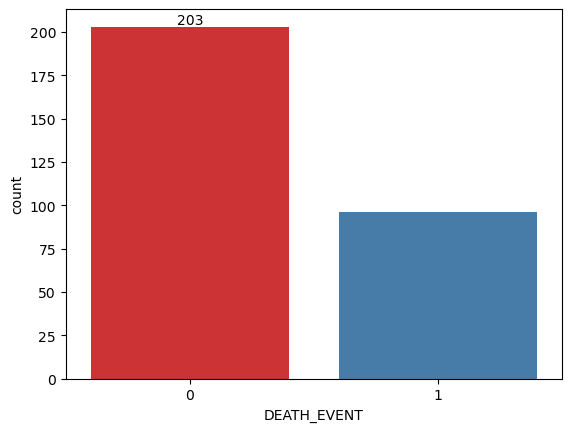

In [6]:
ax = sns.countplot(x= df['DEATH_EVENT'], palette='Set1')
ax.bar_label(ax.containers[0])

<Axes: >

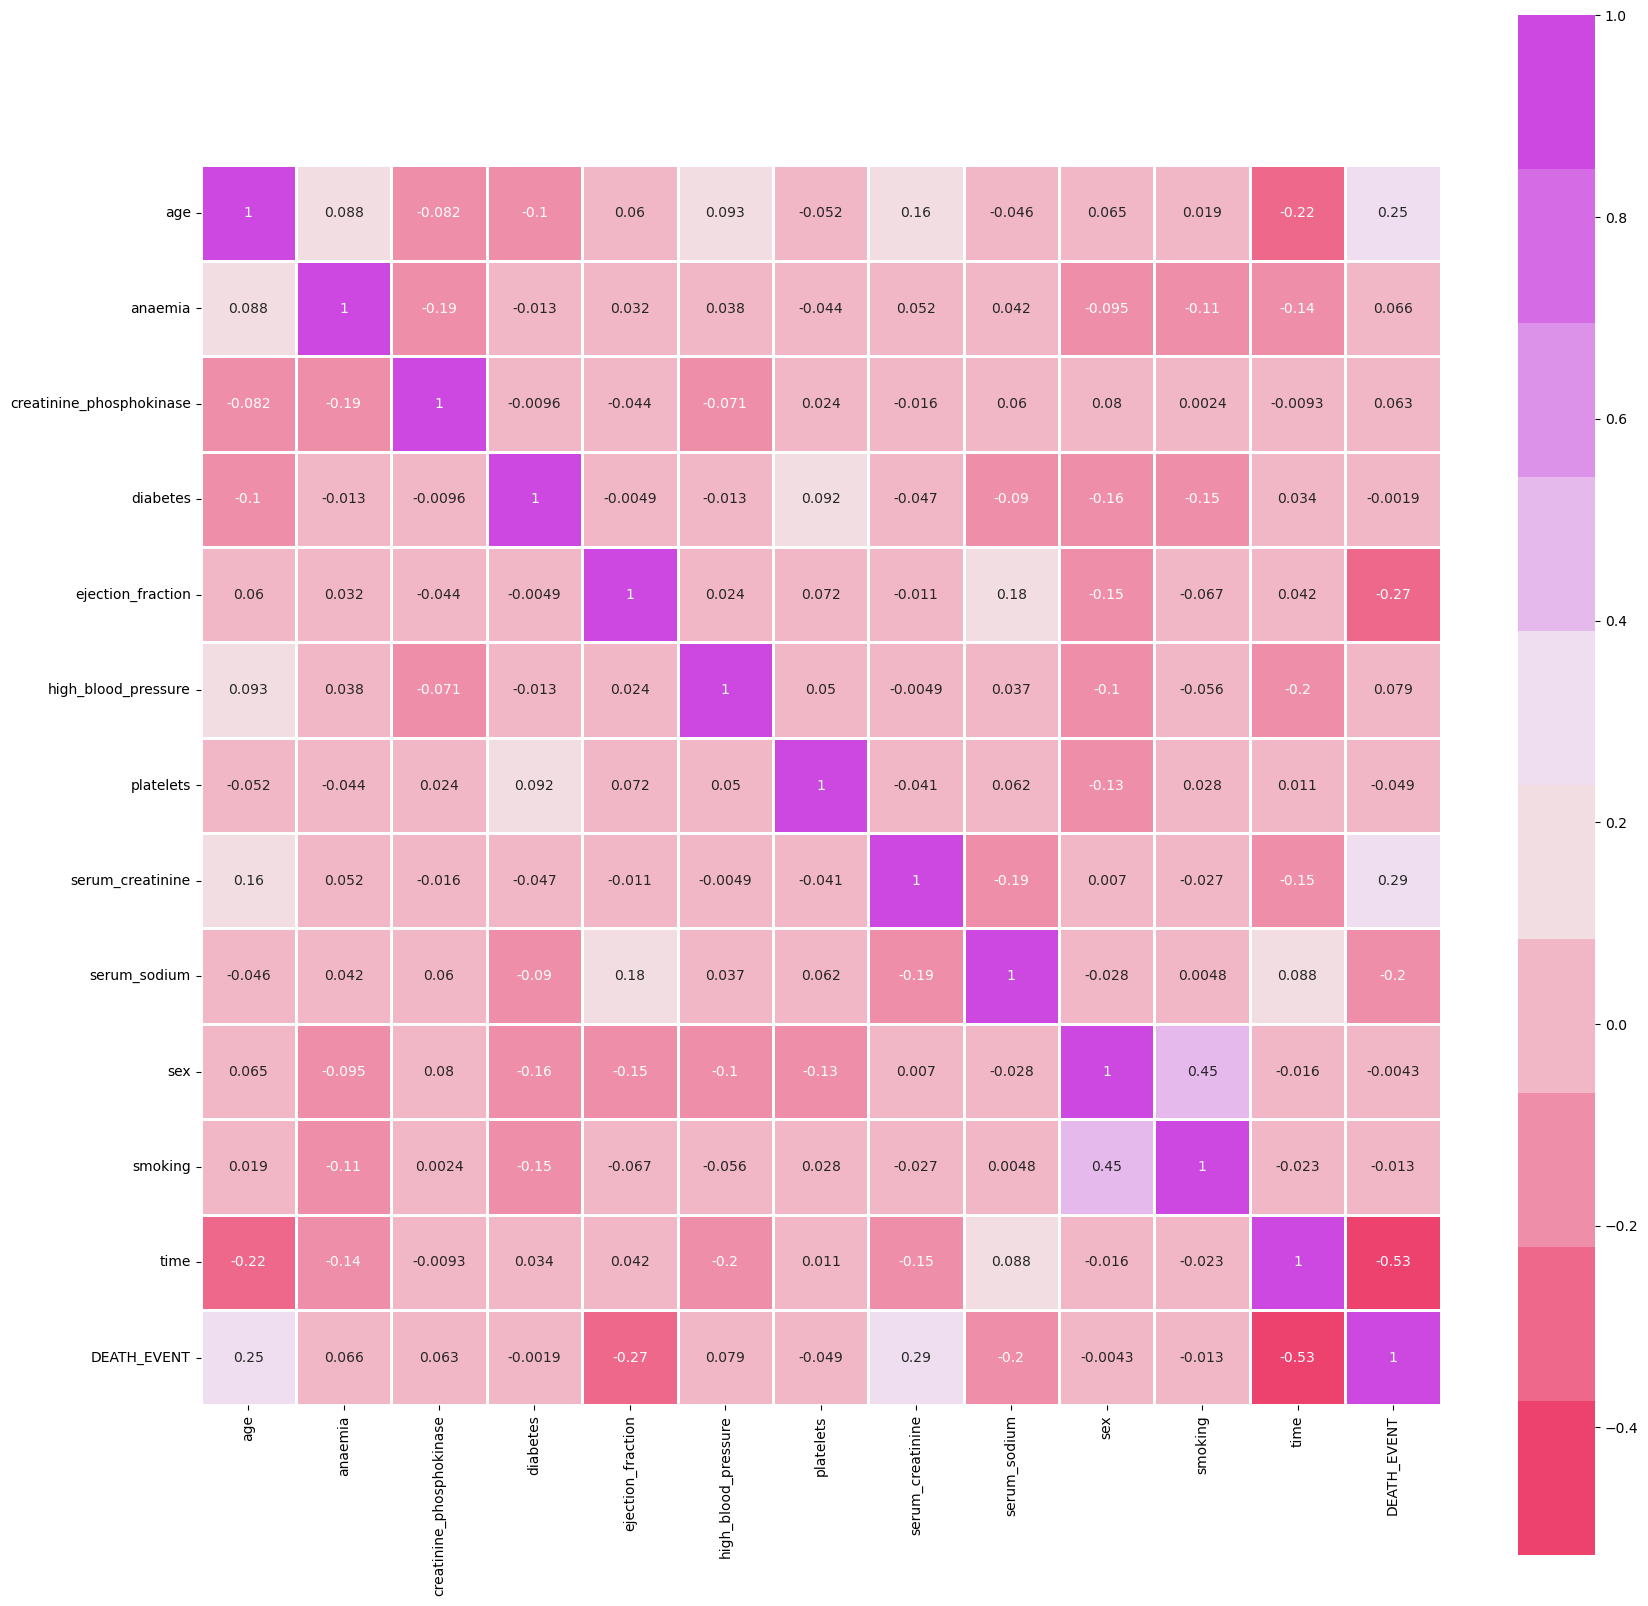

In [7]:
# Bivariate analysis ( Correlation matrix with all feature using heatmap)
cmap = sns.diverging_palette(2, 300, s= 80, l =55, n = 10)
corrmat = df.corr()

plt.figure(figsize= (20, 20))
sns.heatmap(corrmat, cmap=cmap, annot =True, square=True ,linewidths=2)

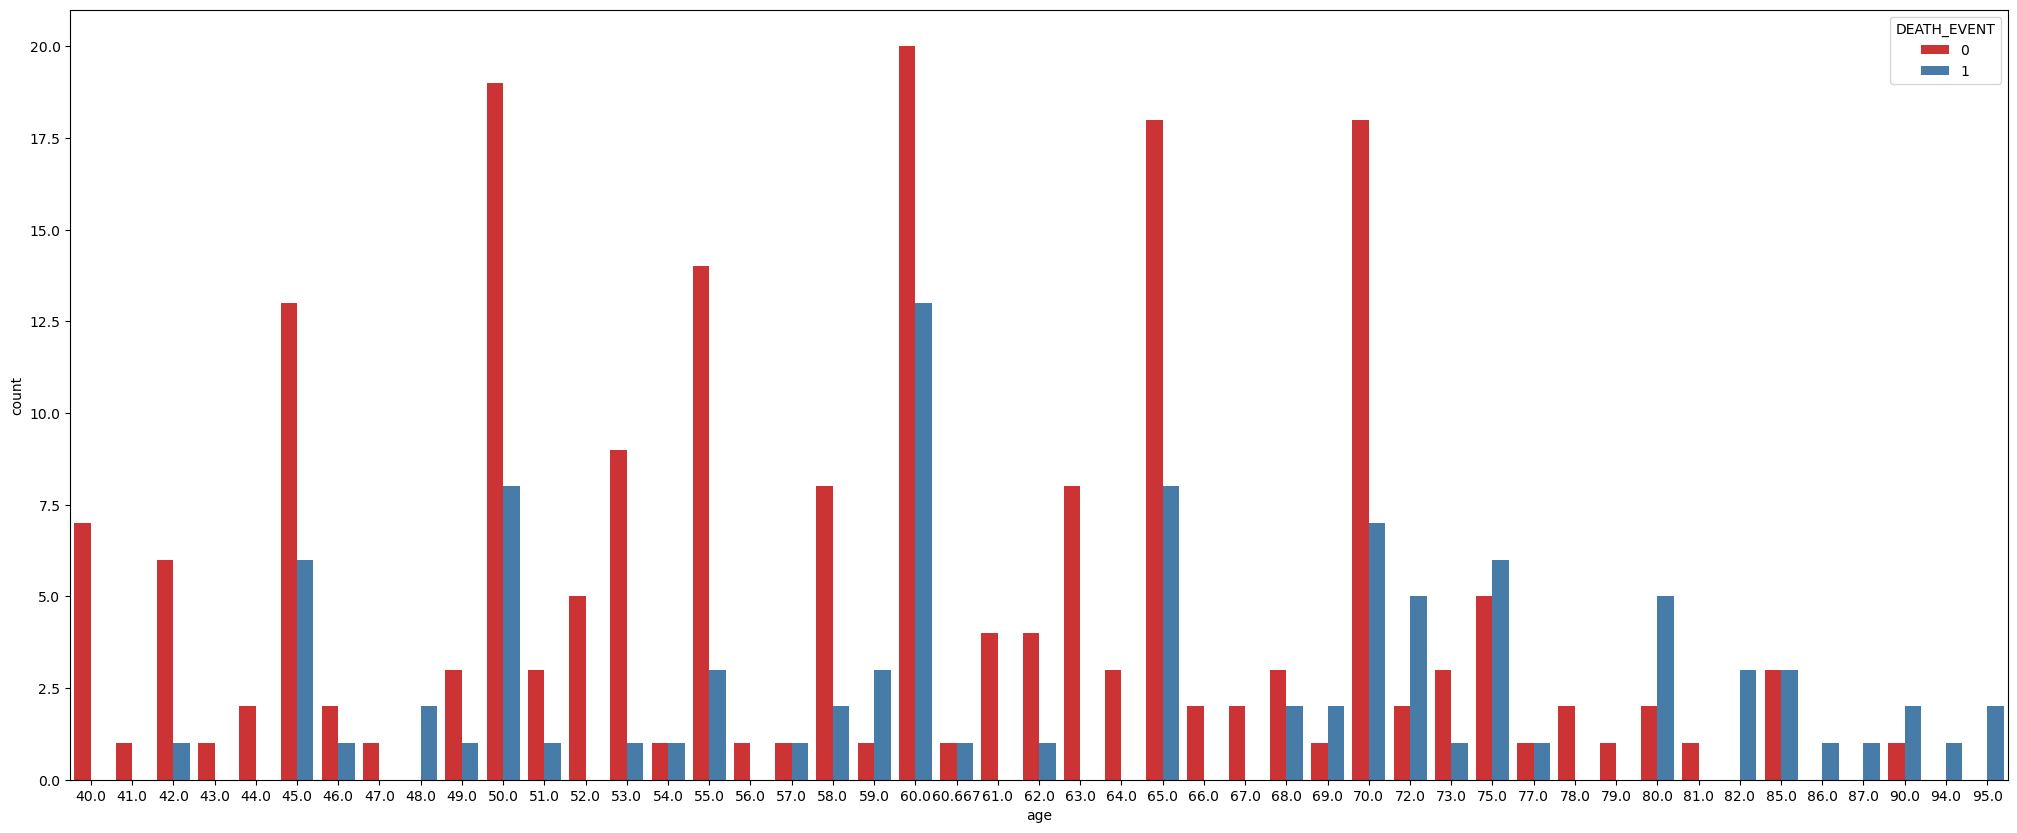

In [8]:
fig, ax =plt.subplots(figsize=(25, 10))
age_plot = sns.countplot(x= df['age'], data= df, hue='DEATH_EVENT', palette='Set1', ax =ax,)
#plt.legend()
plt.show()

In [9]:
df.dtypes

age                         float64
anaemia                       int64
creatinine_phosphokinase      int64
diabetes                      int64
ejection_fraction             int64
high_blood_pressure           int64
platelets                   float64
serum_creatinine            float64
serum_sodium                  int64
sex                           int64
smoking                       int64
time                          int64
DEATH_EVENT                   int64
dtype: object

In [10]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,299.0,60.833893,11.894809,40.0,51.0,60.0,70.0,95.0
anaemia,299.0,0.431438,0.496107,0.0,0.0,0.0,1.0,1.0
creatinine_phosphokinase,299.0,581.839465,970.287881,23.0,116.5,250.0,582.0,7861.0
diabetes,299.0,0.418060,0.494067,0.0,0.0,0.0,1.0,1.0
ejection_fraction,299.0,38.083612,11.834841,14.0,30.0,38.0,45.0,80.0
high_blood_pressure,299.0,0.351171,0.478136,0.0,0.0,0.0,1.0,1.0
platelets,299.0,263358.029264,97804.236869,25100.0,212500.0,262000.0,303500.0,850000.0
serum_creatinine,299.0,1.393880,1.034510,0.5,0.9,1.1,1.4,9.4
serum_sodium,299.0,136.625418,4.412477,113.0,134.0,137.0,140.0,148.0
sex,299.0,0.648829,0.478136,0.0,0.0,1.0,1.0,1.0


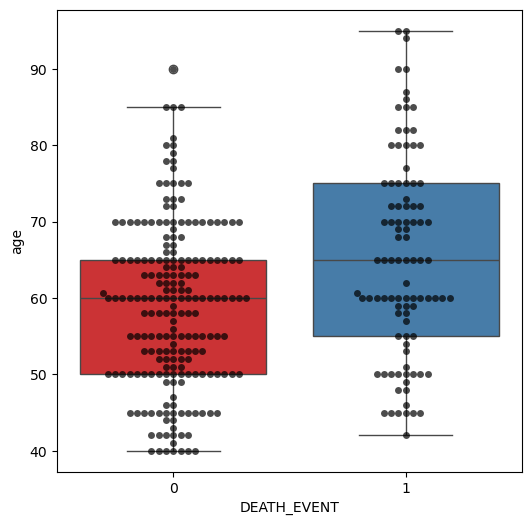

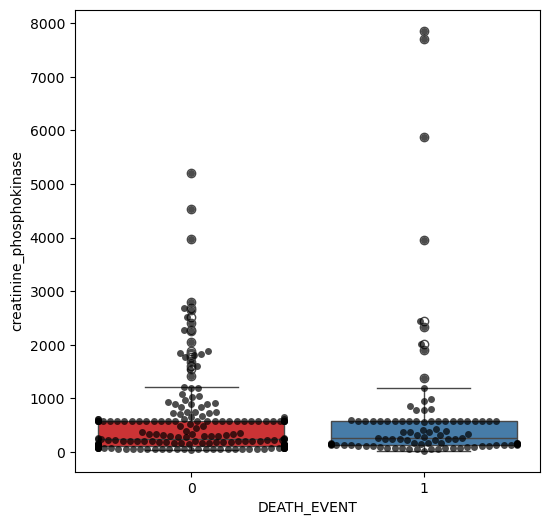

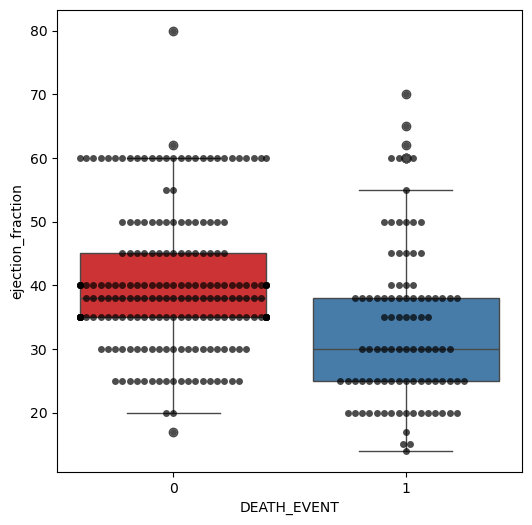

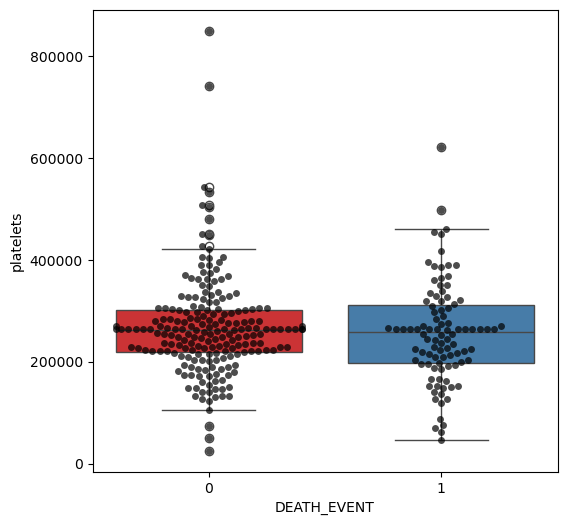

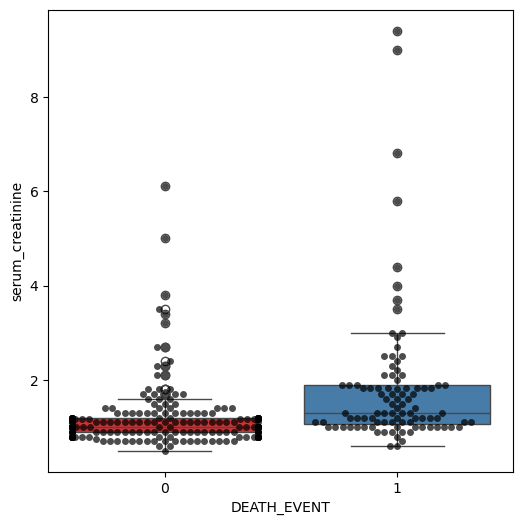

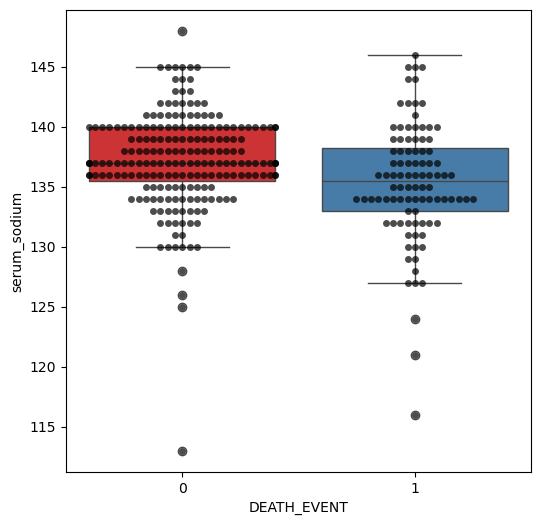

In [11]:
feature = ['age', 
            'creatinine_phosphokinase',
            'ejection_fraction',
            'platelets',
            'serum_creatinine',
            'serum_sodium',
            ]

for i in feature:
    plt.figure(figsize=(6,6))
    sns.swarmplot(x= df['DEATH_EVENT'] ,y= df[i],color='black',alpha= 0.7)
    sns.boxplot(x= df['DEATH_EVENT'] ,y= df[i],palette='Set1',)
    plt.show()

<h1>MODEL BUILDING</h1>

In [12]:
X = df.drop('DEATH_EVENT',axis=1)
y = df['DEATH_EVENT']

In [13]:
col_name = list(X.columns)
scaler = StandardScaler()
X_scaled= scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled , columns=col_name)
X_scaled.describe().T

,count,mean,std,min,25%,50%,75%,max
age,299.0,5.703353e-16,1.001676,-1.754448,-0.828124,-0.070223,0.771889,2.877170
anaemia,299.0,1.009969e-16,1.001676,-0.871105,-0.871105,-0.871105,1.147968,1.147968
creatinine_phosphokinase,299.0,0.000000e+00,1.001676,-0.576918,-0.480393,-0.342574,0.000166,7.514640
diabetes,299.0,9.060014e-17,1.001676,-0.847579,-0.847579,-0.847579,1.179830,1.179830
ejection_fraction,299.0,-3.267546e-17,1.001676,-2.038387,-0.684180,-0.007077,0.585389,3.547716
high_blood_pressure,299.0,0.000000e+00,1.001676,-0.735688,-0.735688,-0.735688,1.359272,1.359272
platelets,299.0,7.723291e-17,1.001676,-2.440155,-0.520870,-0.013908,0.411120,6.008180
serum_creatinine,299.0,1.425838e-16,1.001676,-0.865509,-0.478205,-0.284552,0.005926,7.752020
serum_sodium,299.0,-8.673849e-16,1.001676,-5.363206,-0.595996,0.085034,0.766064,2.582144
sex,299.0,-8.911489e-18,1.001676,-1.359272,-1.359272,0.735688,0.735688,0.735688


In [14]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size= 0.25, random_state=42)

In [15]:
results = []

<h2>1. SUPPORT VECTOR MACHINE</h2>

_____________________________Evaluation for SVM____________________________
[0 0 0 1 0 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 1 0 1 1 1 0 0
 0 0 0 1 1 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 1 0 1 1 0 0 0 1 1 0 1 0 0 1 1 0 0
 0]
___________________________________________________________________________
SVM
Accuracy 	78.6667%
Precision 	85.7143%
Recall 		58.0645%
F1 Score 	69.2308%
Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.93      0.84        44
           1       0.86      0.58      0.69        31

    accuracy                           0.79        75
   macro avg       0.81      0.76      0.76        75
weighted avg       0.80      0.79      0.78        75

 CONFUSION MATRIX


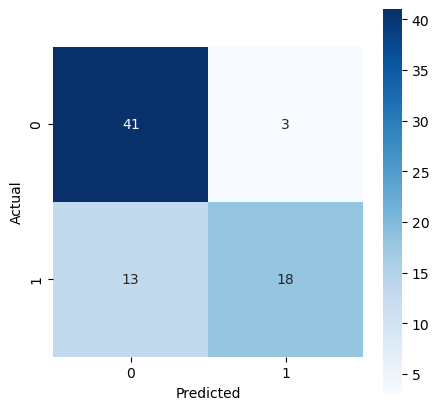

In [16]:
print('Evaluation for SVM'.center(75, '_'))

svm = SVC(kernel='linear', random_state=42)
svm.fit(X_train, y_train)

svm_pred= svm.predict(X_test)
print(svm_pred)

print('_'* 75)

svm_metric = metric(y_test, svm_pred, 'SVM')
results.append(svm_metric)

confusion_matrix_diagram(y_test, svm_pred)


<h2>2. KNEIGHBORS CLASSIFIER</h2>

_____________________Evaluation for K-Nearest Neighbors____________________
[0 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 0 0
 0 0 0 0 1 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 1 1 0 0 0 1 1 0 0 0 0 0 0 0 0
 1]
___________________________________________________________________________
KNN
Accuracy 	70.6667%
Precision 	90.9091%
Recall 		32.2581%
F1 Score 	47.6190%
Classification Report:
              precision    recall  f1-score   support

           0       0.67      0.98      0.80        44
           1       0.91      0.32      0.48        31

    accuracy                           0.71        75
   macro avg       0.79      0.65      0.64        75
weighted avg       0.77      0.71      0.66        75

 CONFUSION MATRIX


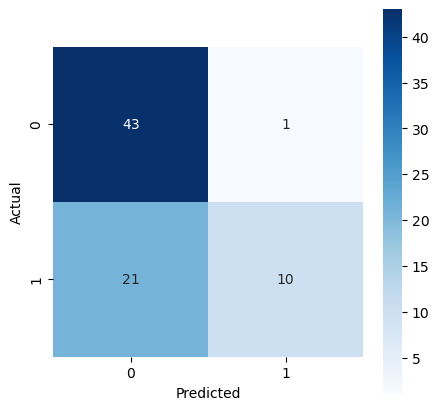

In [17]:
print(f"Evaluation for K-Nearest Neighbors".center(75, '_'))

knn  =KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

knn_pred= knn.predict(X_test)
print(knn_pred)

print('_'*75)

knn_metric = metric(y_test, knn_pred, 'KNN')
results.append(knn_metric)

confusion_matrix_diagram(y_test, knn_pred, )

<h2>3. LOGISTIC REGRESSION</h2>

_____________________Evaluation for Logistic Regression____________________
[0 0 0 1 0 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 1 0 1 1 1 0 0
 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 1 0 1 1 0 0 0 1 1 0 1 0 0 1 1 0 0
 0]
___________________________________________________________________________
Logistic Regression
Accuracy 	77.3333%
Precision 	85.0000%
Recall 		54.8387%
F1 Score 	66.6667%
Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.93      0.83        44
           1       0.85      0.55      0.67        31

    accuracy                           0.77        75
   macro avg       0.80      0.74      0.75        75
weighted avg       0.79      0.77      0.76        75

 CONFUSION MATRIX


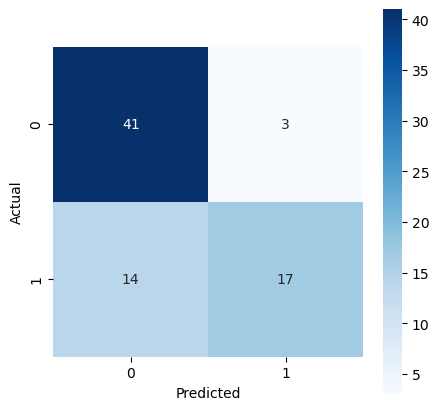

In [18]:
print(f"Evaluation for Logistic Regression".center(75, '_'))

lr  =LogisticRegression(random_state=42,)
lr.fit(X_train, y_train)

lr_pred= lr.predict(X_test)
print(lr_pred)

print('_'*75)

lr_metric = metric(y_test, lr_pred, 'Logistic Regression')
results.append(lr_metric)

confusion_matrix_diagram(y_test, lr_pred)

<h3><u>COMPARISON</u></h3>

In [44]:
result_df = pd.DataFrame(results).sort_values('f1_score', ascending=False).reset_index(drop=True)
result_df

result_df.style.background_gradient(cmap='rocket_r',subset=['accuracy','precision','recall','f1_score'])


,model,accuracy,precision,recall,f1_score
0,SVM,0.786667,0.857143,0.580645,0.692308
1,Logistic Regression,0.773333,0.850000,0.548387,0.666667
2,KNN,0.706667,0.909091,0.322581,0.476190


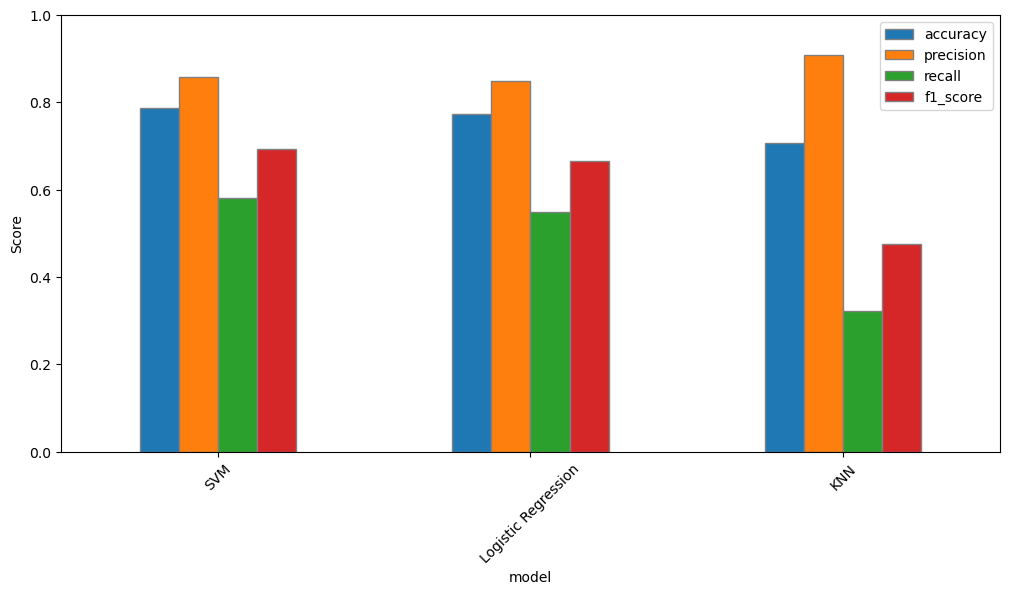

In [59]:


# plt.figure(figsize=(10, 6),edgecolor ='grey')

# plt.bar(x= result_df['model'], height=result_df['accuracy'], color= 'b', width=0.15, label = 'Accuracy')
# plt.bar(x= result_df['model'], height=result_df['precision'], color= 'g', width=0.15, label = 'Precision')
# plt.bar(x= result_df['model'], height=result_df['recall'], color= 'r', width=0.15, label = 'Recall')
# plt.bar(x= result_df['model'], height=result_df['f1_score'], color= 'y', width=0.15, label = 'F1 Score')
# plt.title('Model Evaluation Metrics', fontsize= 15)

result_df.set_index('model').plot(kind='bar', figsize=(10, 6), edgecolor ='grey')
plt.xticks(rotation= 45)
plt.tight_layout()
plt.ylim(0, 1)
plt.ylabel('Score')
plt.legend()
plt.show()